In [1]:
import numpy as np
import sys

sys.path.append('..')
from coronal_diffusion.dataset import CoronalFieldDataset, CoronalFieldDatasetHDF
from coronal_diffusion import visualization_tools

/home/dedasilv/.micromamba/envs/coronal-diffusion-modeling/lib/python3.11/site-packages/ai/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Test Visualization Tools

In [2]:
def read_sh_coefficients(dataset_path, index):
    ds = CoronalFieldDataset(dataset_path)
    arr = ds[index]
    nmax = 90

    H = np.zeros((nmax + 1, nmax + 1))
    G = np.zeros((nmax + 1, nmax + 1))

    G[np.triu_indices(nmax + 1)] = arr[:arr.shape[0]//2]
    H[np.triu_indices(nmax + 1)] = arr[arr.shape[0]//2:]

    G = G.T 
    H = H.T
    
    return G, H, nmax

In [3]:
import config


In [4]:
G, H, nmax = read_sh_coefficients(config.train_wsa_dir, 2000)
print(G[:3, :3])

[[ 2.17389839e-07  0.00000000e+00  0.00000000e+00]
 [-1.32854523e+02 -5.73170891e+01  0.00000000e+00]
 [ 9.58014526e+01 -1.09065228e+01 -1.86282234e+01]]


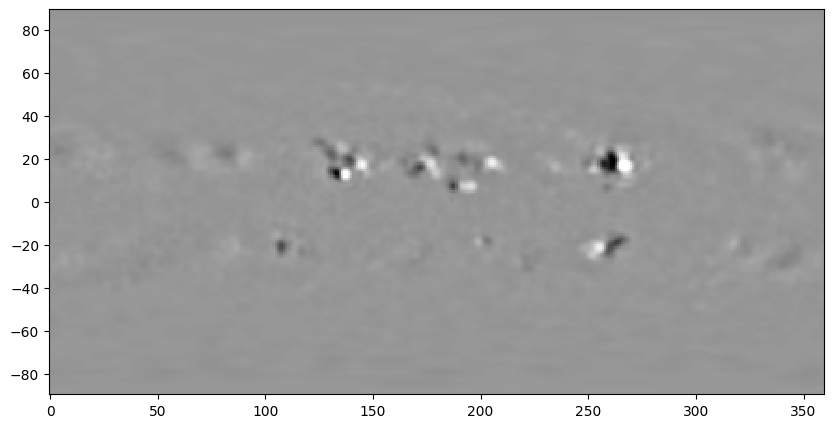

In [5]:
sh = visualization_tools.Visualizer(G, H)
sh.plot_magnetogram()